In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rice
from scipy.special import i0
from scipy.optimize import minimize_scalar

### Вычисление шума по СКО

In [2]:
def calc_snr_like_evm(id_set: int):
    data_psk8 = np.load('data_psk8.npy')[id_set,:].flatten()
    psk8_lut = np.exp(1j*2*np.pi/8*np.arange(0, 8, 1))
    fig3_1 = plt.figure(figsize=(7,5))

    ax_1 = fig3_1.add_subplot(111)
    ax_1.set_title(r'Constellation')
    ax_1.scatter(np.real(data_psk8), np.imag(data_psk8), label='rec')
    ax_1.scatter(np.real(psk8_lut), np.imag(psk8_lut), label='lut table')
    ax_1.set_xlabel('I')
    ax_1.set_ylabel('Q')
    ax_1.legend()
    ax_1.grid()
    plt.show()

    err_vec = np.zeros_like(data_psk8)
    for j_smp in range(len(data_psk8)):
        closest_id = np.argmin(np.abs(psk8_lut-data_psk8[j_smp])**2)
        err_vec[j_smp] = (psk8_lut[closest_id]-data_psk8[j_smp])

    print("sigma_noise_est: ", np.sqrt(np.mean(np.concat([np.real(err_vec)**2, np.imag(err_vec)**2]))))

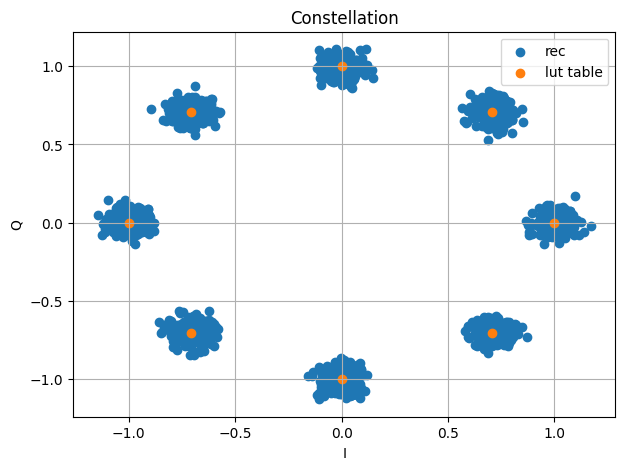

sigma_noise_est:  0.050888467872611524


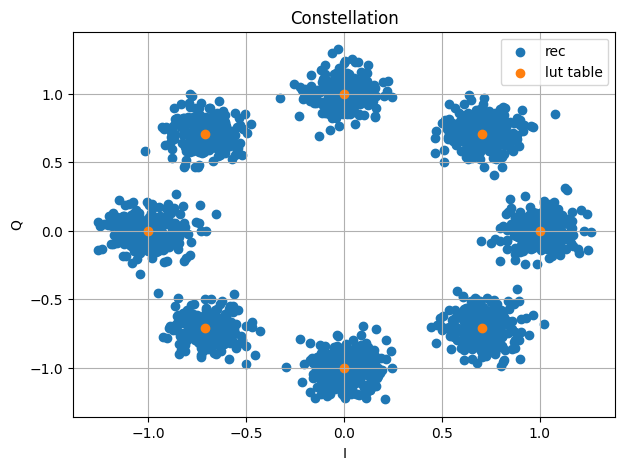

sigma_noise_est:  0.09911630382677467


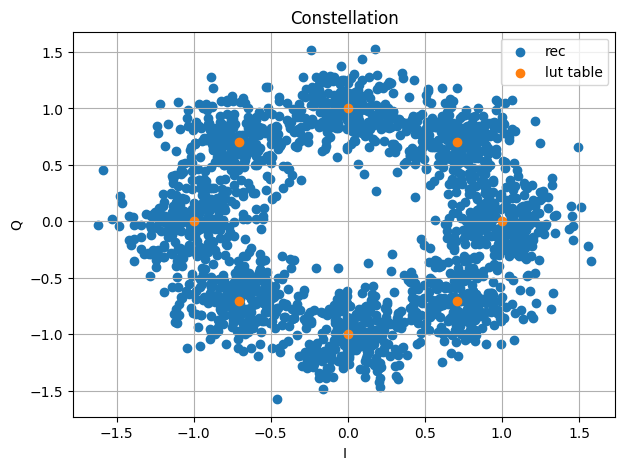

sigma_noise_est:  0.19130869106498888


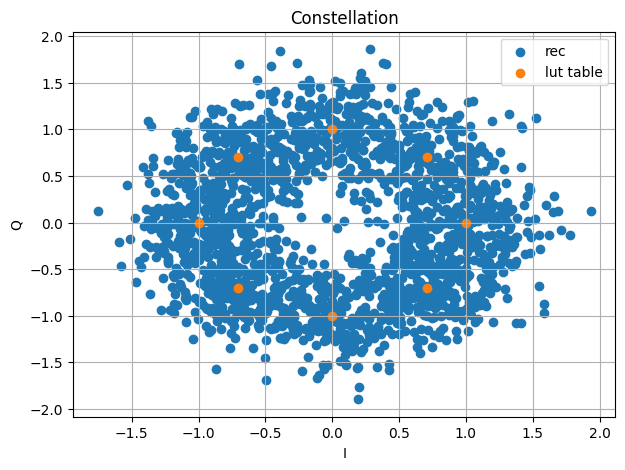

sigma_noise_est:  0.2527982407617197


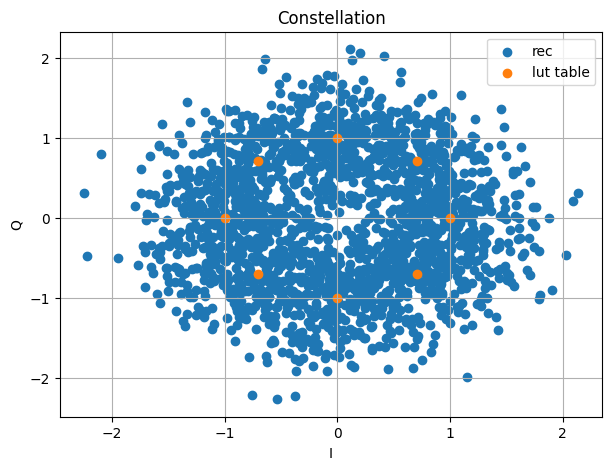

sigma_noise_est:  0.3209659979946527


In [3]:
for i in range(0, 5):
    calc_snr_like_evm(i)

### Вычисление шума по ММП

In [4]:
def calc_snr_max_likelihood(id_set: int):
    data_psk8 = np.load('data_psk8.npy')[id_set,:].flatten()
    psk8_lut = np.exp(1j*2*np.pi/8*np.arange(0, 8, 1))
    fig3_1 = plt.figure(figsize=(7,5))
    ax_1 = fig3_1.add_subplot(111)
    ax_1.set_title(r'Constellation')
    ax_1.scatter(np.real(data_psk8), np.imag(data_psk8), label='rec')
    ax_1.scatter(np.real(psk8_lut), np.imag(psk8_lut), label='lut table')
    ax_1.set_xlabel('I')
    ax_1.set_ylabel('Q')
    ax_1.legend()
    ax_1.grid()
    plt.show()

    def calc_l_rice(sigma: float):
        out = -np.sum(rice.logpdf(np.abs(data_psk8), b=1/sigma, loc=0, scale=sigma))
        return out

    sigma = minimize_scalar(calc_l_rice, bounds=(0.001, 0.9), method='bounded').x

    print("sigma_noise_est: ", np.round(sigma, 4))

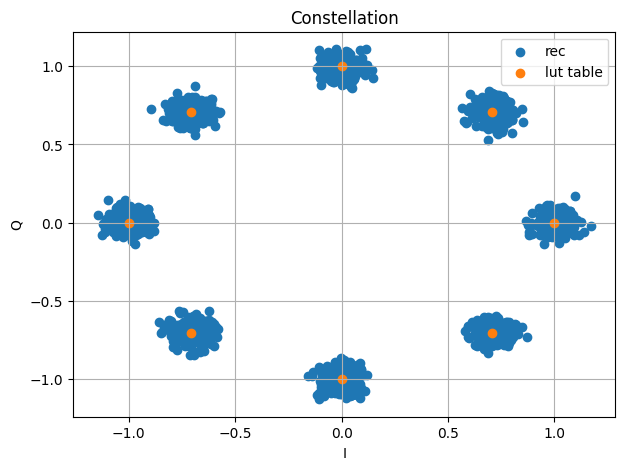

sigma_noise_est:  0.051


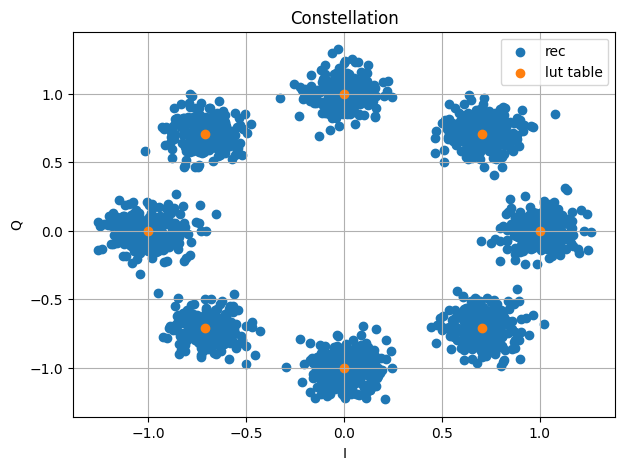

sigma_noise_est:  0.101


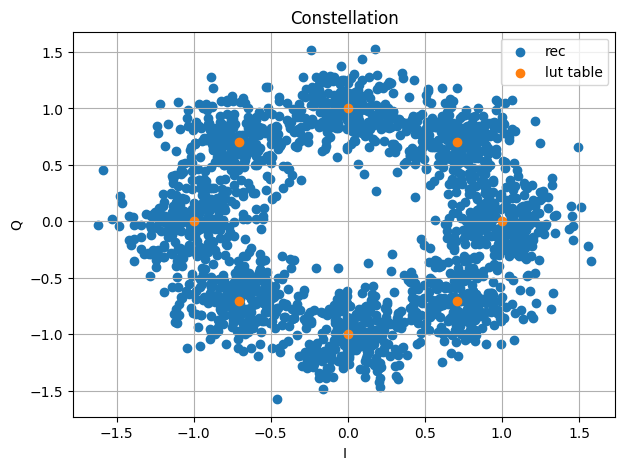

sigma_noise_est:  0.1999


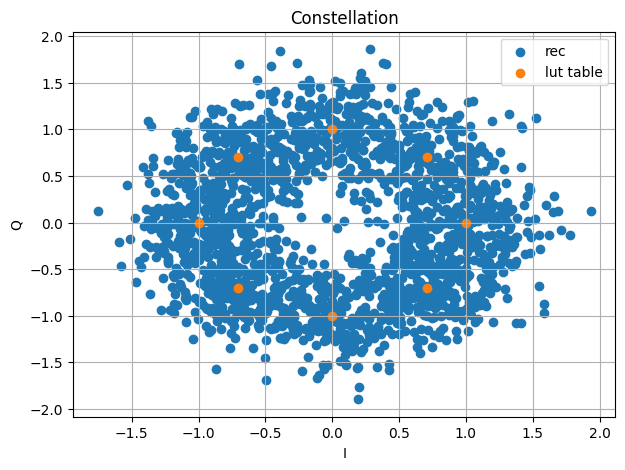

sigma_noise_est:  0.289


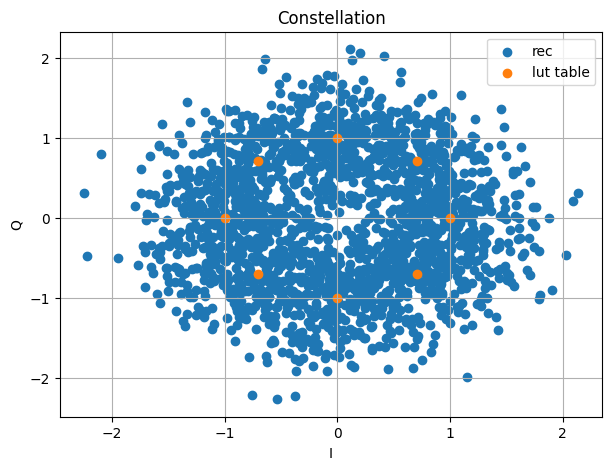

sigma_noise_est:  0.4018


In [5]:
for i in range(0, 5):
    calc_snr_max_likelihood(i)

### QPSK

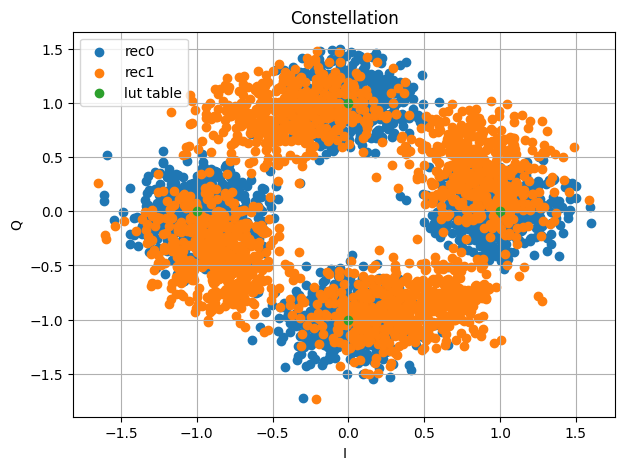

In [6]:
data_qpsk_full = np.load('data_df_qpsk.npy')
data_qpsk0 = data_qpsk_full[0, :].flatten()
data_qpsk1 = data_qpsk_full[1, :].flatten()
qpsk_lut = np.exp(1j*2*np.pi/4*np.arange(0, 4, 1))

fig3_1 = plt.figure(figsize=(7,5))


ax_1 = fig3_1.add_subplot(111)
ax_1.set_title(r'Constellation')
ax_1.scatter(np.real(data_qpsk0), np.imag(data_qpsk0), label='rec0')
ax_1.scatter(np.real(data_qpsk1), np.imag(data_qpsk1), label='rec1')
ax_1.scatter(np.real(qpsk_lut), np.imag(qpsk_lut), label='lut table')
ax_1.set_xlabel('I')
ax_1.set_ylabel('Q')
ax_1.legend()
ax_1.grid()
plt.show()

In [7]:
# For QPSK
def phase_detector_4(sample):
    if sample.real > 0:
        a = 1.0
    else:
        a = -1.0
    if sample.imag > 0:
        b = 1.0
    else:
        b = -1.0

    # if sample.real < sample.imag:
    #     a = 0
    # else:
    #     b = 0 
    return a * sample.imag - b * sample.real

In [8]:
def process_costas_loop(samples):
    N = len(samples)
    phase = 0
    freq = 0
    # These next two params is what to adjust, to make the feedback loop faster or slower (which impacts stability)
    alpha = 0.132
    beta = 0.00932
    out = np.zeros(N, dtype=np.complex64)
    for i in range(N):
        out[i] = samples[i] * np.exp(-1j*phase) # adjust the input sample by the inverse of the estimated phase offset
        error = phase_detector_4(out[i]) # This is the error formula for 2nd order Costas Loop (e.g. for BPSK)
        # error = np.real(out[i]) * np.imag(out[i])

        # Advance the loop (recalc phase and freq offset)
        freq += (beta * error)
        phase += freq + (alpha * error)

        # Optional: Adjust phase so its always between 0 and 2pi, recall that phase wraps around every 2pi
        while phase >= 2*np.pi:
            phase -= 2*np.pi
        while phase < 0:
            phase += 2*np.pi
    return out

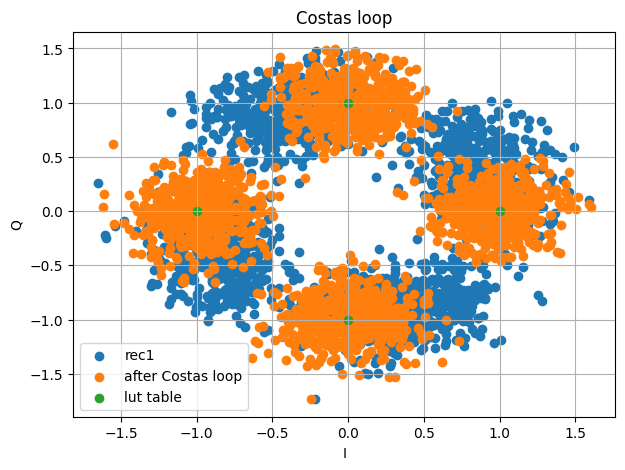

In [9]:
out_cl = process_costas_loop(data_qpsk1*np.exp(1j*np.pi/4)) * np.exp(-1j*np.pi/4)

fig3_1 = plt.figure(figsize=(7,5))


ax_1 = fig3_1.add_subplot(111)
ax_1.set_title(r'Costas loop')
ax_1.scatter(np.real(data_qpsk1), np.imag(data_qpsk1), label='rec1')
ax_1.scatter(np.real(out_cl), np.imag(out_cl), label='after Costas loop')
ax_1.scatter(np.real(qpsk_lut), np.imag(qpsk_lut), label='lut table')
ax_1.set_xlabel('I')
ax_1.set_ylabel('Q')
ax_1.legend()
ax_1.grid()
plt.show()